In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

from dataset import NNUEIterableDataset

In [2]:
dataloader = DataLoader(
    NNUEIterableDataset("../data/nnue/dataset_v0/val", batch_size=1000, random_hflip=False, hflip=False),
    batch_size=None,
    num_workers=2,
    persistent_workers=True,
    prefetch_factor=4,
)

# flip_dataloader = DataLoader(
#     NNUEIterableDataset("../data/nnue/dataset_v0/val", batch_size=1000, random_hflip=False, hflip=True),
#     batch_size=None,
#     num_workers=2,
#     persistent_workers=True,
#     prefetch_factor=4,
# )

In [3]:
buckets = np.linspace(-10000, 10000, 100)
counts = np.zeros(100)
wins = np.zeros(100)

idx_counts = np.zeros(1696*45)

# for (batch, flip_batch) in zip(dataloader, flip_dataloader):
for batch in dataloader:
    b, w, s, r, t = batch

    # flip_b, flip_w, flip_s, flip_r, flip_t = flip_batch

    # b = torch.cat([b, flip_b], dim=0)
    # w = torch.cat([w, flip_w], dim=0)
    # s = torch.cat([s, flip_s], dim=0)
    # r = torch.cat([r, flip_r], dim=0)
    # t = torch.cat([t, flip_t], dim=0)

    np.add.at(idx_counts, b.flatten(), 1)
    np.add.at(idx_counts, w.flatten(), 1)

    s = np.clip(s, -10000, 10000)

    # digitize returns the indices of the buckets [1, ..., len(buckets)]
    bin_indices = np.digitize(s, buckets) - 1  # Shift to zero-indexed

    # keep only scores that fell within the buckets
    mask = (bin_indices >= 0) & (bin_indices < len(buckets))
    bin_indices = bin_indices[mask]
    r_valid = r[mask]

    # Update counts and wins per bucket
    counts += np.bincount(bin_indices, minlength=len(buckets))
    wins += np.bincount(bin_indices, weights=r_valid, minlength=len(buckets))

# total = counts.sum() / 2 # remove the flip counts
total = counts.sum()
print(f'total: {total.item()}')

perf = wins / counts

total: 23351217.0


In [4]:
num_kb = 45
num_features = len(idx_counts)
kb_features = num_features // num_kb
total_features = idx_counts.sum()
counts_per_kb = np.zeros(num_kb)
for i in range(num_kb):
    counts_per_kb[i] = idx_counts[i*kb_features:(i+1)*kb_features].sum()
print(counts_per_kb)

for i in range(num_kb):
    print(f"KB {i+1}: {(counts_per_kb[i]/total_features * 100):.3f}%")


[3.7094900e+08 2.2249060e+08 2.7195660e+08 3.1528760e+07 1.1456180e+08
 6.3016640e+07 1.1424588e+08 1.5921608e+08 1.1677032e+08 2.0769160e+08
 1.3817480e+07 2.9293880e+07 2.3426240e+07 2.2906560e+07 2.4875040e+07
 3.8630400e+06 8.3373600e+06 6.8192800e+06 9.0512800e+06 8.5333600e+06
 1.2015600e+06 2.4753200e+06 2.8609600e+06 3.0234400e+06 3.8297200e+06
 6.6004000e+05 1.2782800e+06 1.7088400e+06 1.8259200e+06 3.3311600e+06
 3.2636000e+05 8.0744000e+05 8.9040000e+05 1.0788400e+06 1.9255200e+06
 2.7204000e+05 5.5348000e+05 6.4476000e+05 7.4484000e+05 1.6167200e+06
 1.0897600e+06 2.2306800e+06 2.4176400e+06 1.6954400e+06 6.2574000e+06]
KB 1: 19.857%
KB 2: 11.910%
KB 3: 14.558%
KB 4: 1.688%
KB 5: 6.133%
KB 6: 3.373%
KB 7: 6.116%
KB 8: 8.523%
KB 9: 6.251%
KB 10: 11.118%
KB 11: 0.740%
KB 12: 1.568%
KB 13: 1.254%
KB 14: 1.226%
KB 15: 1.332%
KB 16: 0.207%
KB 17: 0.446%
KB 18: 0.365%
KB 19: 0.485%
KB 20: 0.457%
KB 21: 0.064%
KB 22: 0.133%
KB 23: 0.153%
KB 24: 0.162%
KB 25: 0.205%
KB 26: 0.035%
K

In [5]:
buckets = buckets / (127*64)

In [6]:
targets = torch.sigmoid(torch.tensor(buckets*3)).numpy()

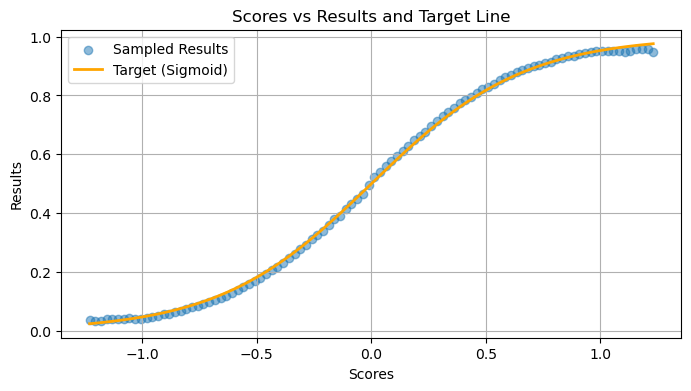

In [7]:
plt.figure(figsize=(8, 4))
plt.scatter(buckets, perf, alpha=0.5, label='Sampled Results')
plt.plot(buckets, targets, color='orange', label='Target (Sigmoid)', linewidth=2)

plt.xlabel('Scores')
plt.ylabel('Results')
plt.title('Scores vs Results and Target Line')
# plt.xlim(-10000, 10000)
plt.grid(True)
plt.legend()
plt.show()

In [9]:
empty_idxs = np.where(idx_counts == 0)[0]
print(f'{empty_idxs.shape[0]} empty features')
print(f'{empty_idxs.shape[0] - (9*4*2*num_kb) - (80*num_kb)} after removing impossible features')
for idx in empty_idxs:
    print(idx)


9674 empty features
2834 after removing impossible features
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
77
78
79
80
157
238
243
244
245
246
247
248
249
250
251
319
324
325
326
327
328
329
330
331
332
333
334
335
336
337
338
339
340
341
400
481
562
567
568
569
570
571
572
573
574
575
643
724
805
876
877
878
885
886
887
957
958
959
966
967
968
1038
1039
1040
1048
1120
1125
1126
1127
1128
1129
1130
1131
1132
1133
1191
1193
1197
1198
1199
1200
1201
1202
1203
1204
1205
1206
1207
1208
1209
1210
1211
1212
1213
1214
1281
1283
1291
1363
1371
1372
1373
1444
1449
1450
1451
1452
1453
1454
1455
1456
1457
1524
1525
1526
1533
1534
1535
1605
1606
1607
1614
1615
1616
1656
1657
1695
1696
1697
1698
1699
1700
1701
1702
1703
1704
1705
1706
1707
1708
1709
1710
1711
1712
1713
1714
1715
1716
1717
1718
1719
1720
1721
1722
1723
1724
1725
17